In [2]:
import tensorflow as tf
import sklearn
import pandas as pd

def check_environment():
    report = {
        "TensorFlow Version": tf.__version__,
        "Scikit-Learn Version": sklearn.__version__,
        "Pandas Version": pd.__version__,
        "GPU Available": tf.config.list_physical_devices('GPU') != []
    }
    
    print("--- Environment Status Report ---")
    for key, value in report.items():
        print(f"{key}: {value}")

check_environment()

--- Environment Status Report ---
TensorFlow Version: 2.13.0
Scikit-Learn Version: 1.3.2
Pandas Version: 2.0.3
GPU Available: False


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,GRU, Dense, Bidirectional
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.layers import TimeDistributed, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("stefancomanita/hourly-electricity-consumption-and-production")

#print("Path to dataset files:", path)


In [4]:
df = pd.read_csv("electricityConsumptionAndProductioction.csv")
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [ ]:
df.describe()

In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')
df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [ ]:
df.describe()

In [ ]:
df['Consumption'].plot(figsize=(15,5))

In [ ]:
df['Consumption']['2019-01-01':'2019-01-07'].plot()

In [6]:
df['Hour'] = df.index.hour
df['Dayofweek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Imbalance'] = df['Consumption'] - df['Production']
df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Hour,Dayofweek,Month,Imbalance
DateTime,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1,1,-175
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1,1,415
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1,1,197
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1,1,79
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,1,103


In [ ]:
sns.boxplot(x='Hour', y='Consumption', data=df)

In [ ]:
sns.boxplot(x='Dayofweek', y='Consumption', data=df)

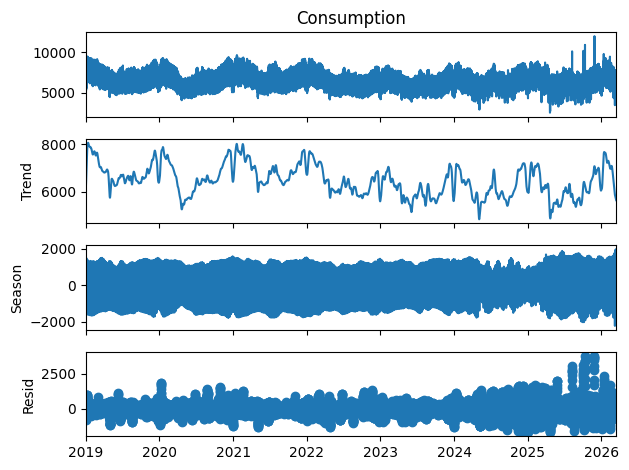

In [6]:
from statsmodels.tsa.seasonal import STL

stl= STL(df['Consumption'], period=24*7)
res = stl.fit()
fig = res.plot()

In [ ]:
from statsmodels.tsa.seasonal import STL

stl2 = STL(df['Consumption'], period=168)
res2 = stl.fit()
fig2 = res.plot()

In [ ]:
from statsmodels.tsa.seasonal import MSTL
res = MSTL(df['Consumption'], periods=(24, 168)).fit()
fig_res = res.plot()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10,8))

plot_acf(df['Consumption'], lags=200, ax=ax[0])
plot_pacf(df['Consumption'], lags=200, ax=ax[1])

plt.tight_layout()
plt.show()

In [ ]:
diff = df['Consumption'].diff().dropna()

In [ ]:
plot_acf(diff, lags=200)


In [ ]:
plot_pacf(diff, lags=200)

In [ ]:
diff_total = df['Consumption'].diff().diff(24).dropna()

In [ ]:
plot_acf(diff_total, lags=200)


In [ ]:
plot_pacf(diff_total, lags=200)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [8]:
y = df['Consumption'].dropna().astype(float)

train_size = int(len(y) * 0.8)
train = y.iloc[:train_size]
test = y.iloc[train_size:]

In [9]:
# Modelo Naive
naive_pred = np.repeat(train.iloc[-1], len(test))

mae_naive = mean_absolute_error(test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 1055.761104919599
Naive RMSE: 1252.2868721048587


In [ ]:
# Modelo SARIMAX (S + ARIMA + X)
model_arima_110 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_110 = model_arima_110.fit(disp=False)
print(results_arima_110.summary())

In [ ]:
pred_arima_110 = results_arima_110.forecast(steps=len(test))

mae_arima_110 = mean_absolute_error(test, pred_arima_110)
rmse_arima_110 = np.sqrt(mean_squared_error(test, pred_arima_110))

print("ARIMA(1,1,0) MAE:", mae_arima_110)
print("ARIMA(1,1,0) RMSE:", rmse_arima_110)

In [22]:
# 2do Modelo SARIMAX (0,1,1)
model_arima_011 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_011 = model_arima_011.fit(disp=False)
print(results_arima_011.summary())

a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                62642
Model:               SARIMAX(0, 1, 1)   Log Likelihood             -429806.442
Date:                Sat, 04 Apr 2026   AIC                         859616.884
Time:                        19:36:15   BIC                         859634.974
Sample:                             0   HQIC                        859622.492
                              - 62642                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6042      0.001    420.260      0.000       0.601       0.607
sigma2      5.339e+04    114.759    465.203      0.000    5.32e+04    5.36e+04
Ljung-Box (L1) (Q):                3505.14   Jarque-

In [23]:
pred_arima_011 = results_arima_011.forecast(steps=len(test))

mae_arima_011 = mean_absolute_error(test, pred_arima_011)
rmse_arima_011 = np.sqrt(mean_squared_error(test, pred_arima_011))

print("ARIMA(0,1,1) MAE:", mae_arima_011)
print("ARIMA(0,1,1) RMSE:", rmse_arima_011)

ARIMA(0,1,1) MAE: 759.5743316361996
ARIMA(0,1,1) RMSE: 976.3308315412274


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
model_arima_111 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima_111 = model_arima_111.fit(disp=False)
print(results_arima_111.summary())

In [ ]:
pred_arima_111 = results_arima_111.forecast(steps=len(test))

mae_arima_111 = mean_absolute_error(test, pred_arima_111)
rmse_arima_111 = np.sqrt(mean_squared_error(test, pred_arima_111))

print("ARIMA(1,1,1) MAE:", mae_arima_111)
print("ARIMA(1,1,1) RMSE:", rmse_arima_111)

In [ ]:
# Modelo estacionario mínimo, ahora sí con módulo S aplicado
model_sarima_110_010_24 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarima_110_010_24 = model_sarima_110_010_24.fit(disp=False)
print(results_sarima_110_010_24.summary())

In [ ]:
pred_sarima_110_010_24 = results_sarima_110_010_24.forecast(steps=len(test))

mae_sarima_110_010_24 = mean_absolute_error(test, pred_sarima_110_010_24)
rmse_sarima_110_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_010_24)

In [ ]:
model_sarima_011_010_24 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=False
)

results_sarima_011_010_24 = model_sarima_011_010_24.fit(disp=False, low_memory=True)
print(results_sarima_011_010_24.summary())

In [ ]:
pred_sarima_110_010_24 = results_sarima_110_010_24.forecast(steps=len(test))

mae_sarima_110_010_24 = mean_absolute_error(test, pred_sarima_110_010_24)
rmse_sarima_110_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_010_24)

In [ ]:
model_sarima_011_010_24 = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_011_010_24 = model_sarima_011_010_24.fit(disp=False, low_memory=True)
print(results_sarima_011_010_24.summary())

In [ ]:
pred_sarima_011_010_24 = results_sarima_011_010_24.forecast(steps=len(test))

mae_sarima_011_010_24 = mean_absolute_error(test, pred_sarima_011_010_24)
rmse_sarima_011_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_011_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_011_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_011_010_24)

In [ ]:
model_sarima_111_010_24 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_111_010_24 = model_sarima_111_010_24.fit(disp=False, low_memory=True)
print(results_sarima_111_010_24.summary())

In [ ]:
pred_sarima_111_010_24 = results_sarima_111_010_24.forecast(steps=len(test))

mae_sarima_111_010_24 = mean_absolute_error(test, pred_sarima_111_010_24)
rmse_sarima_111_010_24 = np.sqrt(mean_squared_error(test, pred_sarima_111_010_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_111_010_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_111_010_24)

In [ ]:
model_sarima_110_110_24 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_110_110_24 = model_sarima_110_110_24.fit(disp=False, low_memory=True)
print(results_sarima_110_110_24.summary())

In [ ]:
pred_sarima_110_110_24 = results_sarima_110_110_24.forecast(steps=len(test))

mae_sarima_110_110_24 = mean_absolute_error(test, pred_sarima_110_110_24)
rmse_sarima_110_110_24 = np.sqrt(mean_squared_error(test, pred_sarima_110_110_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_110_110_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_110_110_24)

In [ ]:
model_sarima_111_110_24 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results_sarima_111_110_24 = model_sarima_111_110_24.fit(disp=False, low_memory=True)
print(results_sarima_111_110_24.summary())

In [ ]:
pred_sarima_111_110_24 = results_sarima_111_110_24.forecast(steps=len(test))

mae_sarima_111_110_24 = mean_absolute_error(test, pred_sarima_111_110_24)
rmse_sarima_111_110_24 = np.sqrt(mean_squared_error(test, pred_sarima_111_110_24))

print("SARIMA(1,1,0)(0,1,0,24) MAE:", mae_sarima_111_110_24)
print("SARIMA(1,1,0)(0,1,0,24) RMSE:", rmse_sarima_111_110_24)

In [ ]:
results_table = pd.DataFrame({
    'Modelo': [
        'Naive',
        'ARIMA(1,1,0)',
        'ARIMA(0,1,1)',
        'ARIMA(1,1,1)',
        'SARIMA(1,1,0)(0,1,0,24)',
        'SARIMA(0,1,1)(0,1,0,24)',
        'SARIMA(1,1,1)(0,1,0,24)',
        'SARIMA(1,1,0)(1,1,0,24)',
        'SARIMA(1,1,1)(1,1,0,24)'
    ],
    'AIC': [
        np.nan,
        results_arima_110.aic,
        results_arima_011.aic,
        results_arima_111.aic,
        results_sarima_110_010_24.aic,
        results_sarima_011_010_24.aic,
        results_sarima_111_010_24.aic,
        results_sarima_110_110_24.aic,
        results_sarima_111_110_24.aic
    ],
    'MAE': [
        mae_naive,
        mae_arima_110,
        mae_arima_011,
        mean_absolute_error(test, results_arima_111.forecast(steps=len(test))),
        mae_sarima_110_010_24,
        mean_absolute_error(test, results_sarima_011_010_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_111_010_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_110_110_24.forecast(steps=len(test))),
        mean_absolute_error(test, results_sarima_111_110_24.forecast(steps=len(test)))
    ]
    ,
    'RMSE': [
        rmse_naive,
        rmse_arima_110,
        rmse_arima_011,
        rmse_arima_111,
        rmse_sarima_110_010_24,
        rmse_sarima_011_010_24,
        rmse_sarima_111_010_24,
        rmse_sarima_110_110_24,
        rmse_sarima_111_110_24
    ]
})

print(results_table.sort_values('MAE'))

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# usa una ventana más manejable para test
test_horizon = 168  # 7 días horarios
train = y.iloc[:-test_horizon].copy()
test = y.iloc[-test_horizon:].copy()

def walk_forward_sarimax(train, test, order, seasonal_order,
                         simple_differencing=False,
                         enforce_stationarity=False,
                         enforce_invertibility=False):
    history = train.copy()
    preds = []

    for t in range(len(test)):
        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            simple_differencing=simple_differencing,
            enforce_stationarity=enforce_stationarity,
            enforce_invertibility=enforce_invertibility
        )
        results = model.fit(disp=False, low_memory=True)

        # 1-step ahead
        yhat = results.forecast(steps=1)
        preds.append(float(yhat.iloc[0]))

        # agregar el valor real al historial
        history = pd.concat([history, test.iloc[t:t+1]])

    preds = pd.Series(preds, index=test.index)
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    return preds, mae, rmse

In [10]:
def walk_forward_naive(train, test):
    history = train.copy()
    preds = []

    for t in range(len(test)):
        preds.append(float(history.iloc[-1]))
        history = pd.concat([history, test.iloc[t:t+1]])

    preds = pd.Series(preds, index=test.index)
    mae = mean_absolute_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))
    return preds, mae, rmse

In [11]:
pred_naive, mae_naive, rmse_naive = walk_forward_naive(train, test)
print(mae_naive, rmse_naive)

344.01785714285717 421.55522007375095


In [16]:
pred_arima011, mae_arima011, rmse_arima011 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(0,0,0,0),
    simple_differencing=False
)

a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index w

In [21]:
pred_arima011

DateTime
2026-03-08 00:00:00    5441.614839
2026-03-08 01:00:00    5532.064142
2026-03-08 02:00:00    5191.882521
2026-03-08 03:00:00    5148.759009
2026-03-08 04:00:00    5365.708018
                          ...     
2026-03-14 19:00:00    6856.937645
2026-03-14 20:00:00    7298.264396
2026-03-14 21:00:00    6863.034534
2026-03-14 22:00:00    6465.074816
2026-03-14 23:00:00    5819.959870
Length: 168, dtype: float64

In [17]:
print(mae_arima011, rmse_arima011)

249.68656036377317 314.089359565356


In [18]:
pred_sarima011, mae_sarima011, rmse_sarima011 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(0,1,0,24),
    simple_differencing=True
)


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

In [19]:

results_table = pd.DataFrame({
    "Modelo": ["Naive", "ARIMA(0,1,1)", "SARIMA(0,1,1)(0,1,0,24)"],
    "MAE": [mae_naive, mae_arima011, mae_sarima011],
    "RMSE": [rmse_naive, rmse_arima011, rmse_sarima011]
})

print(results_table.sort_values("MAE"))

                    Modelo          MAE         RMSE
1             ARIMA(0,1,1)   249.686560   314.089360
0                    Naive   344.017857   421.555220
2  SARIMA(0,1,1)(0,1,0,24)  5770.148559  5842.701153


In [13]:
pred_sarima011_10024, mae_sarima011_10024, rmse_sarima011_10024 = walk_forward_sarimax(
    train, test,
    order=(0,1,1),
    seasonal_order=(1,0,0,24),
    simple_differencing=True
)


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index w

In [14]:
print(mae_sarima011_10024, rmse_sarima011_10024)

5771.27065055922 5841.8379151651625


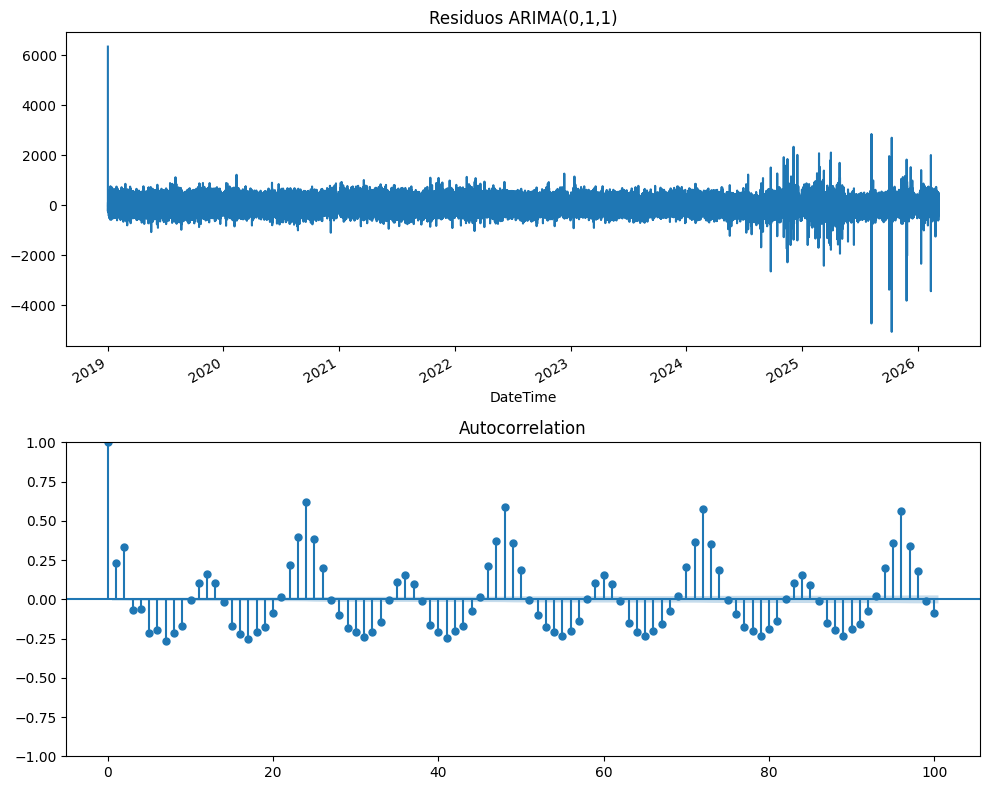

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = results_arima_011.resid.dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
resid.plot(ax=ax[0], title='Residuos ARIMA(0,1,1)')
plot_acf(resid, lags=100, ax=ax[1])
plt.tight_layout()
plt.show()

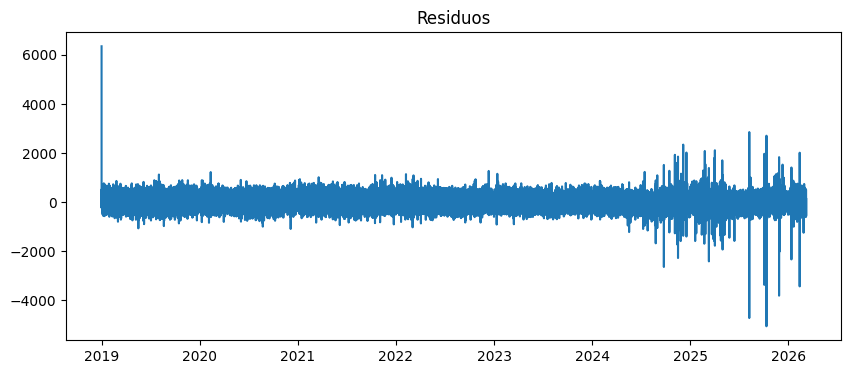

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title("Residuos")
plt.show()

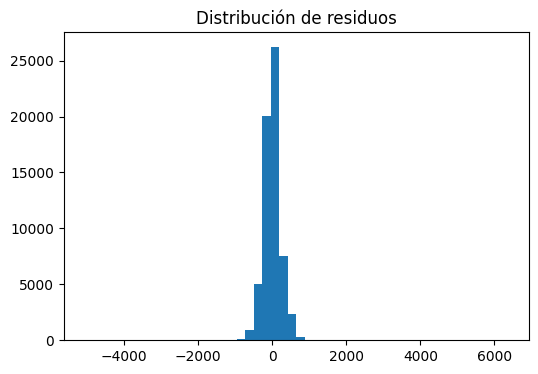

In [26]:
plt.figure(figsize=(6,4))
plt.hist(resid, bins=50)
plt.title("Distribución de residuos")
plt.show()

In [27]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(resid, lags=[24], return_df=True)
print(ljung)

         lb_stat  lb_pvalue
24  79224.778022        0.0


In [28]:
model = SARIMAX(
    train,
    order=(0,1,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

results = model.fit(disp=False, low_memory=True)

a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [31]:
preds = results.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test, preds)
rmse_sarima = np.sqrt(mean_squared_error(test, preds))

print(mae_sarima, rmse_sarima)

5774.926699103453 5848.554415758872


a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
a:\Downloads\New folder (14)\venv_ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


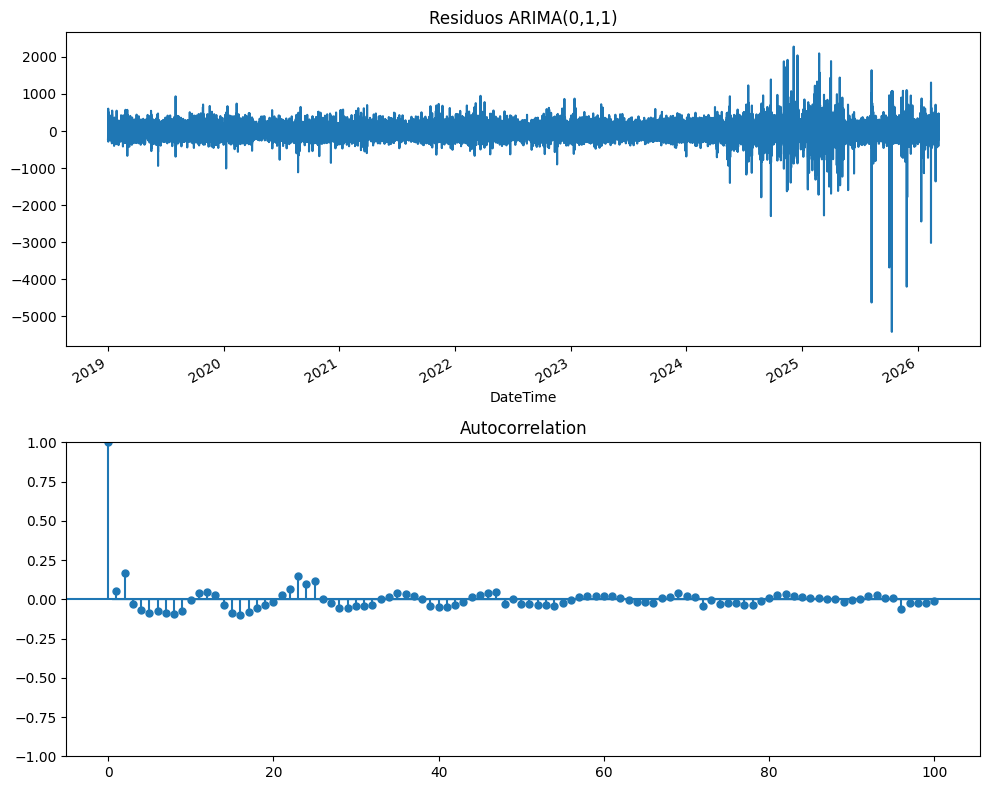

In [29]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = results.resid.dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
resid.plot(ax=ax[0], title='Residuos ARIMA(0,1,1)')
plot_acf(resid, lags=100, ax=ax[1])
plt.tight_layout()
plt.show()

In [30]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(resid, lags=[24], return_df=True)
print(ljung)

        lb_stat  lb_pvalue
24  8843.653695        0.0
